In [23]:
import json
from pathlib import Path
import pandas as pd
import matplotlib.pyplot as plt

In [24]:
def read_jsonl(path):
    with open(path) as f:
        return pd.DataFrame(json.loads(line) for line in f)

ROOT = Path("..")

wsd_raw      = read_jsonl(ROOT / "logs/wsd_intermediate_10k_20260606-071741/metrics.jsonl")
wsd_beta_raw = read_jsonl(ROOT / "logs/wsd_beta_intermediate_10k_20260606-082147/metrics.jsonl")
cosine_raw   = read_jsonl(ROOT / "logs/cosine_intermediate_10k_20260606-162651/metrics.jsonl")

def split(raw):
    train = raw[raw["train_loss"].notna()].reset_index(drop=True)
    val   = raw[raw["validation_loss"].notna()].reset_index(drop=True) if "validation_loss" in raw.columns else None
    return train, val

wsd_train,      wsd_val      = split(wsd_raw)
wsd_beta_train, wsd_beta_val = split(wsd_beta_raw)
cosine_train,   cosine_val   = split(cosine_raw)

print(f"WSD steps:      {wsd_train['step'].min()} → {wsd_train['step'].max()}")
print(f"WSD-beta steps: {wsd_beta_train['step'].min()} → {wsd_beta_train['step'].max()}")
print(f"Cosine steps:   {cosine_train['step'].min()} → {cosine_train['step'].max()}")

WSD steps:      5 → 10000
WSD-beta steps: 5 → 10000
Cosine steps:   5 → 10000


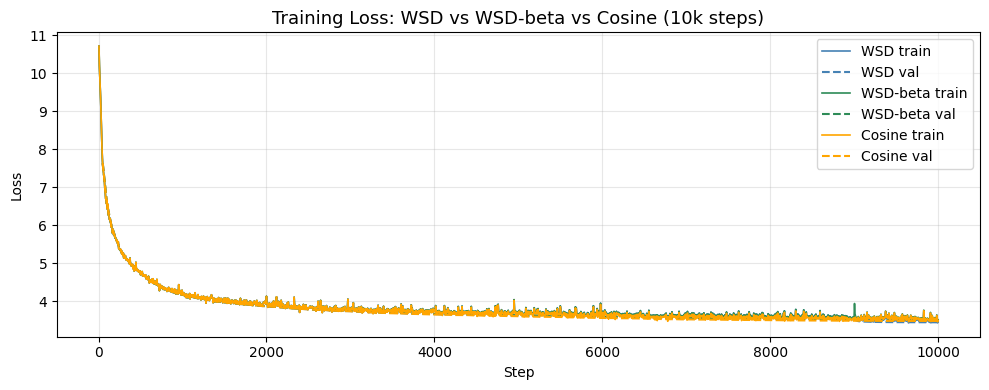

In [25]:
fig, ax = plt.subplots(figsize=(10, 4))

runs = [
    (wsd_train,      wsd_val,      "steelblue", "WSD"),
    (wsd_beta_train, wsd_beta_val, "seagreen",  "WSD-beta"),
    (cosine_train,   cosine_val,   "orange",    "Cosine"),
]

for train_df, val_df, color, name in runs:
    ax.plot(train_df["step"], train_df["train_loss"], color=color, linewidth=1.2, label=f"{name} train")
    if val_df is not None and len(val_df) > 0:
        ax.plot(val_df["step"], val_df["validation_loss"], color=color, linewidth=1.5, linestyle="--", label=f"{name} val")

ax.set_title("Training Loss: WSD vs WSD-beta vs Cosine (10k steps)", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

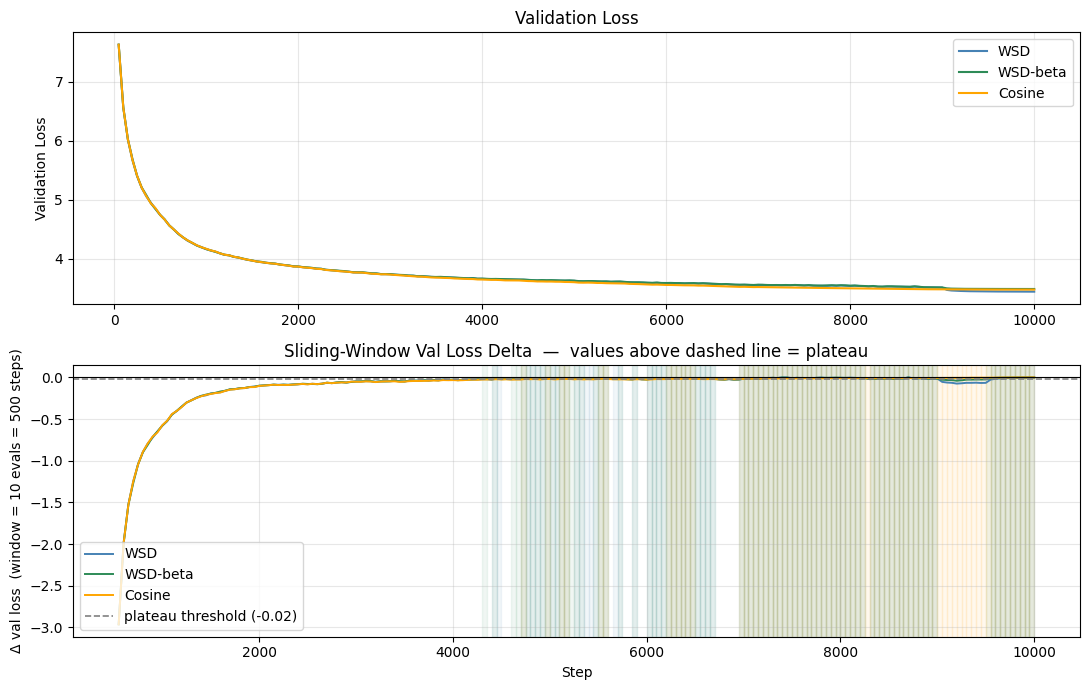

In [4]:
import numpy as np

# Sliding-window val loss delta: delta[i] = val_loss[i] - val_loss[i - W]
# Negative = still improving. Near 0 = plateau.
WINDOW = 10          # eval checkpoints (eval_interval=50 steps → window covers 500 steps)
PLATEAU_THRESHOLD = -0.02  # delta above this (less negative) = plateau

runs_val = [
    (wsd_val,      "steelblue", "WSD"),
    (wsd_beta_val, "seagreen",  "WSD-beta"),
    (cosine_val,   "orange",    "Cosine"),
]

fig, (ax_top, ax_bot) = plt.subplots(2, 1, figsize=(11, 7), sharex=False)

# ── Top: val loss ──────────────────────────────────────────────────────────────
for val_df, color, name in runs_val:
    if val_df is not None and len(val_df) > 0:
        ax_top.plot(val_df["step"], val_df["validation_loss"],
                    color=color, linewidth=1.5, label=name)
ax_top.set_ylabel("Validation Loss")
ax_top.set_title("Validation Loss", fontsize=12)
ax_top.legend()
ax_top.grid(True, alpha=0.3)

# ── Bottom: sliding window delta ───────────────────────────────────────────────
for val_df, color, name in runs_val:
    if val_df is not None and len(val_df) < WINDOW + 1:
        continue
    losses = val_df["validation_loss"].values
    steps  = val_df["step"].values
    delta  = np.full(len(losses), np.nan)
    for i in range(WINDOW, len(losses)):
        delta[i] = losses[i] - losses[i - WINDOW]

    ax_bot.plot(steps, delta, color=color, linewidth=1.4, label=name)

    # Shade plateau region for this run
    plateau_mask = delta >= PLATEAU_THRESHOLD
    for i in range(1, len(steps)):
        if plateau_mask[i]:
            ax_bot.axvspan(steps[i - 1], steps[i], alpha=0.07, color=color)

ax_bot.axhline(0, color="black", linewidth=0.8)
ax_bot.axhline(PLATEAU_THRESHOLD, color="gray", linewidth=1.2, linestyle="--",
               label=f"plateau threshold ({PLATEAU_THRESHOLD})")
ax_bot.set_ylabel(f"Δ val loss  (window = {WINDOW} evals = {WINDOW * 50} steps)")
ax_bot.set_xlabel("Step")
ax_bot.set_title(
    f"Sliding-Window Val Loss Delta  —  values above dashed line = plateau",
    fontsize=12,
)
ax_bot.legend()
ax_bot.grid(True, alpha=0.3)

plt.tight_layout()
plt.show()

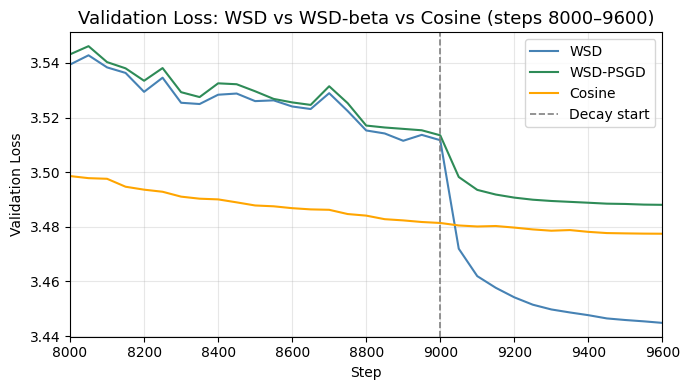

In [16]:
fig, ax = plt.subplots(figsize=(7, 4))

runs = [
    (wsd_val,      "steelblue", "WSD"),
    (wsd_beta_val, "seagreen",  "WSD-PSGD"),
    (cosine_val,   "orange",    "Cosine"),
]

ZOOM_START, ZOOM_END = 8000, 9600
DECAY_START = 9000

for val_df, color, name in runs:
    if val_df is not None and len(val_df) > 0:
        mask = val_df["step"].between(ZOOM_START, ZOOM_END)
        if mask.any():
            ax.plot(val_df.loc[mask, "step"], val_df.loc[mask, "validation_loss"],
                    color=color, linewidth=1.5, linestyle="-", label=f"{name}")

ax.axvline(DECAY_START, color="gray", linewidth=1.2, linestyle="--", label="Decay start")
ax.set_xlim(ZOOM_START, ZOOM_END)
ax.set_title(f"Validation Loss: WSD vs WSD-beta vs Cosine (steps {ZOOM_START}–{ZOOM_END})", fontsize=13)
ax.set_xlabel("Step")
ax.set_ylabel("Validation Loss")
ax.legend()
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()

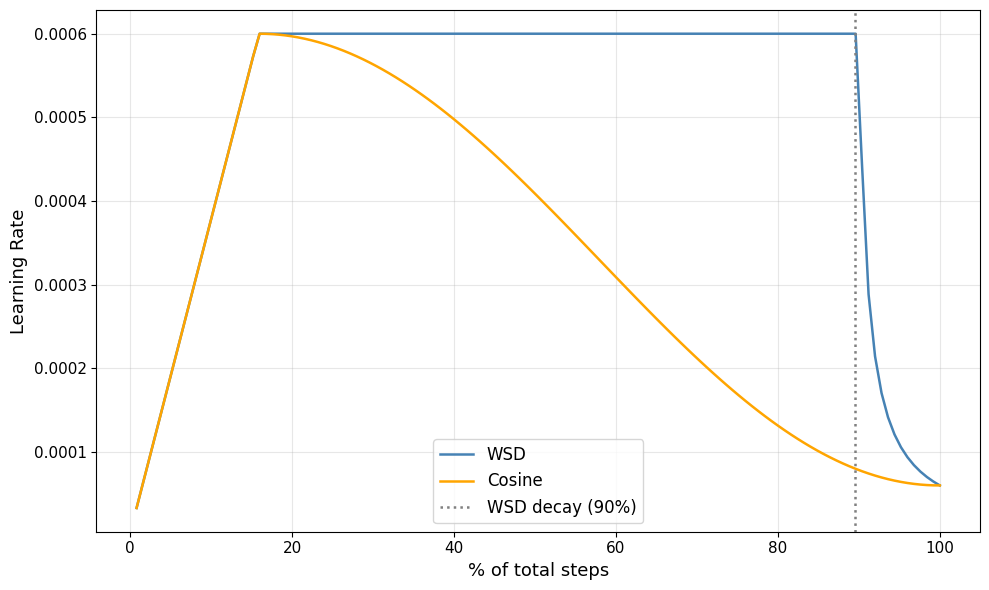

In [34]:
MAX_STEPS = wsd_train["step"].max()

lr_diff = wsd_train["learning_rate"].diff()
decay_step = int(wsd_train.loc[lr_diff[lr_diff < -1e-9].index[0], "step"])
decay_pct = 89.5

fig, ax = plt.subplots(figsize=(10, 6))

ax.plot(100 * wsd_train["step"] / MAX_STEPS,    wsd_train["learning_rate"],    color="steelblue", linewidth=1.8, label="WSD")
ax.plot(100 * cosine_train["step"] / MAX_STEPS, cosine_train["learning_rate"], color="orange",    linewidth=1.8, label="Cosine")

ax.axvline(decay_pct, color="gray", linewidth=1.8, linestyle=":", label=f"WSD decay ({decay_pct:.0f}%)")

ax.set_xlabel("% of total steps", fontsize=13)
ax.set_ylabel("Learning Rate", fontsize=13)
ax.tick_params(labelsize=11)
ax.legend(fontsize=12)
ax.grid(True, alpha=0.3)
plt.tight_layout()
plt.show()